# Carga de datos y exploración inicial

## Dataset Titanic - Fuente: Kaggle

In [25]:
import os
import zipfile
import pandas as pd # Manejo de datos
import numpy as np # Cálculos numéricos
import seaborn as sns # Gráficas
import matplotlib.pyplot as plt # Gráficas

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

### Cargando Datos

In [28]:
# URL pública del dataset Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Cargar el dataset directamente en un DataFrame
df = pd.read_csv(url)

# Confirmar que se cargó correctamente
print("Dataset cargado correctamente.")
df.head(3)

Dataset cargado correctamente.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## Descripción de las columnas del dataset Titanic

- **PassengerId**  
  Identificador único asignado a cada pasajero.

- **Survived**  
  Indica si el pasajero sobrevivió al desastre.  
  0 = No sobrevivió  
  1 = Sobrevivió

- **Pclass**  
  Clase del pasajero en el barco.  
  1 = Primera clase  
  2 = Segunda clase  
  3 = Tercera clase

- **Name**  
  Nombre completo del pasajero.

- **Sex**  
  Sexo del pasajero.

- **Age**  
  Edad del pasajero en años.

- **SibSp**  
  Número de hermanos/as o cónyuges que viajaban con el pasajero.

- **Parch**  
  Número de padres o hijos que viajaban con el pasajero.

- **Ticket**  
  Número del boleto del pasajero.

- **Fare**  
  Tarifa pagada por el pasajero.

- **Cabin**  
  Número de cabina asignada.

- **Embarked**  
  Puerto de embarque del pasajero.  
  C = Cherbourg  
  Q = Queenstown  
  S = Southampton

### Exploración Básica

In [36]:
# Mostrar el número de filas y columnas del dataset
df.shape

(891, 12)

In [38]:
# Viendo valores únicos de Age
print("Valores únicos de Age:")
print(df["Age"].unique())

Valores únicos de Age:
[22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ]


In [37]:
# Mostrar el tipo de dato de cada columna
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

#### Tipos
- int64 = Entero
- float64 = Número con punto decimal
- str = Texto

In [39]:
# Mostrar un resumen general del dataset
# Incluye tipos de datos, cantidad de valores no nulos y uso de memoria
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [40]:
# Mostrar estadísticas descriptivas de las variables numéricas
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [41]:
# Contar valores faltantes por columna
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [42]:
# Seleccionando filas con valores faltantes
with_empties = df[df.isnull().any(axis=1)]
with_empties.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


### Exploración Visual

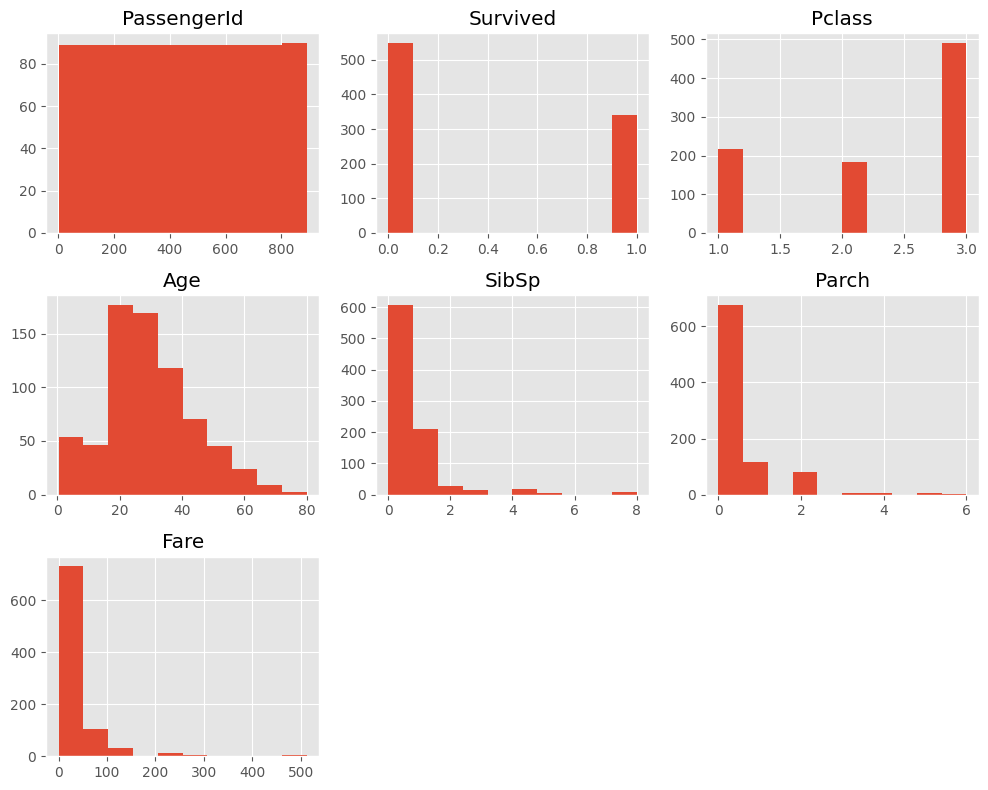

In [43]:
# Graficar histogramas para las variables numéricas
df.hist(figsize=(10, 8))

plt.tight_layout()
plt.show()

## Matriz de correlación

In [44]:
# Seleccionar únicamente las variables numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [45]:
# Calcular la matriz de correlación
corr_matrix = df_numeric.corr()

corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


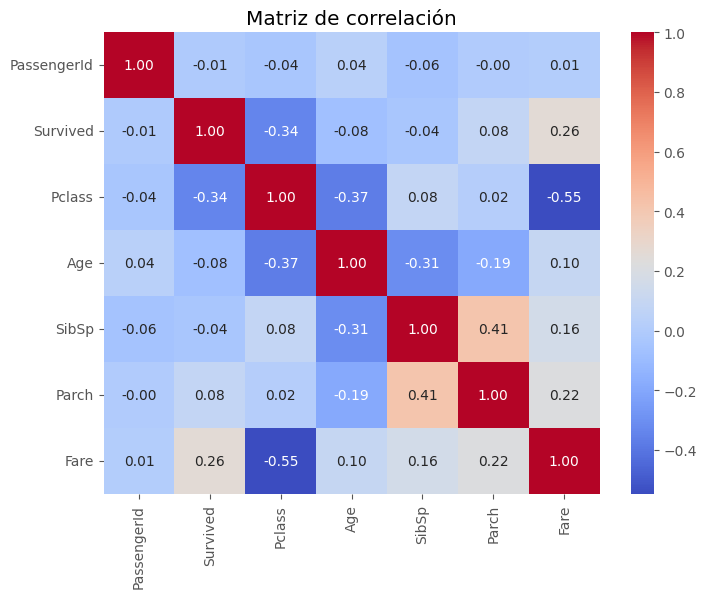

In [46]:
# Visualizar la matriz de correlación con un mapa de calor

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap="coolwarm", 
            fmt=".2f")

plt.title("Matriz de correlación")
plt.show()

In [47]:
# Ver correlación únicamente con la variable Survived
corr_matrix["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

### Distribución

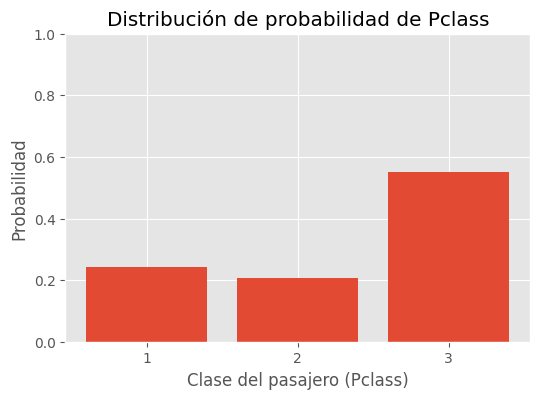

In [48]:
# Calcular frecuencia relativa de Pclass
pclass_prob = df["Pclass"].value_counts(normalize=True).sort_index()

# Graficar con matplotlib
plt.figure(figsize=(6,4))

plt.bar(pclass_prob.index.astype(str), pclass_prob.values)

plt.xlabel("Clase del pasajero (Pclass)")
plt.ylabel("Probabilidad")
plt.title("Distribución de probabilidad de Pclass")

plt.ylim(0, 1)
plt.show()

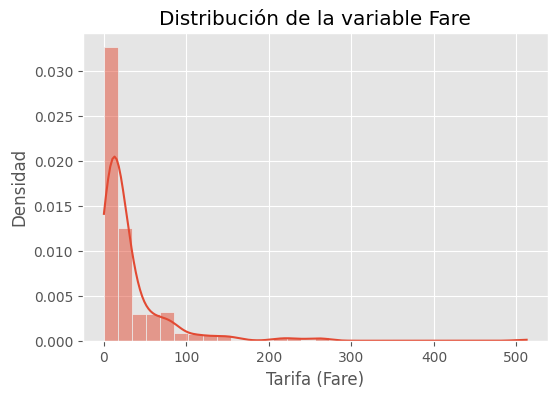

In [49]:
# Graficar la distribución de la variable continua Fare
plt.figure(figsize=(6,4))

sns.histplot(df["Fare"],
             stat="density",
             kde=True,
             bins=30)

plt.xlabel("Tarifa (Fare)")
plt.ylabel("Densidad")
plt.title("Distribución de la variable Fare")

plt.show()

### Buscar un relato

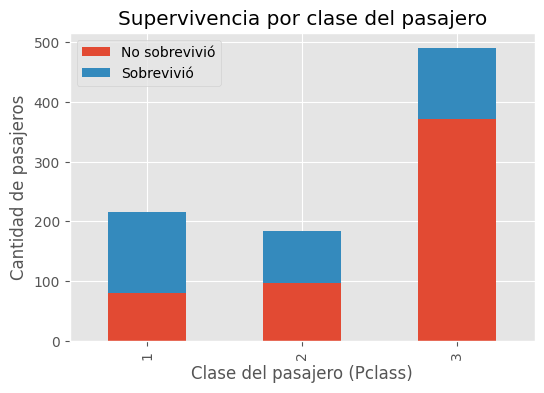

In [50]:
# Crear tabla cruzada entre clase y supervivencia
tabla = pd.crosstab(df["Pclass"], df["Survived"])

# Graficar barras apiladas
tabla.plot(kind="bar", stacked=True, figsize=(6,4))

plt.xlabel("Clase del pasajero (Pclass)")
plt.ylabel("Cantidad de pasajeros")
plt.title("Supervivencia por clase del pasajero")

plt.legend(["No sobrevivió", "Sobrevivió"])
plt.show()

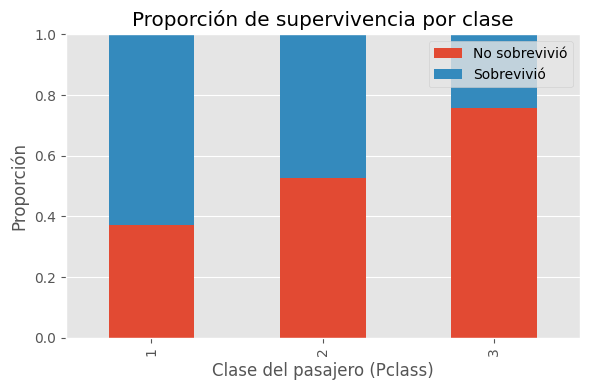

In [51]:
# Crear tabla cruzada normalizada por fila (proporciones dentro de cada clase)
tabla_prop = pd.crosstab(df["Pclass"], df["Survived"], normalize="index")

# Graficar barras apiladas en proporciones
ax = tabla_prop.plot(kind="bar", stacked=True, figsize=(6,4))

ax.set_xlabel("Clase del pasajero (Pclass)")
ax.set_ylabel("Proporción")
ax.set_title("Proporción de supervivencia por clase")
ax.set_ylim(0, 1)

ax.legend(["No sobrevivió", "Sobrevivió"], loc="upper right")

plt.tight_layout()
plt.show()

### ¿Qué conclusiones podemos sacar?

- La mayoría de primera clase sobrevivieron.
- La mayoría en tercera clase no sobrevivieron.
- La probabilidad de sobrevivir aumentó mientras mayor fuera la clase.